In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [15]:
file_path = "/content/Bank Customer Churn Prediction .csv"
df = pd.read_csv(file_path)
df

,active_member,age,balance,churn,country,credit_card,credit_score,estimated_salary,gender,products_number,tenure,customer_id
0,1,50,0.00,0,France,1,822,10062.80,Male,2,7,15592531
1,1,41,0.00,0,France,1,732,170886.17,Male,2,8,15577657
2,1,55,0.00,0,France,1,664,139161.64,Male,2,8,15614049
3,1,29,0.00,0,France,1,769,172290.61,Male,2,8,15640635
4,1,34,0.00,0,France,1,663,180427.24,Male,2,7,15724944
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,38,151532.40,0,France,1,750,46555.15,Male,1,5,15809124
9996,1,33,126679.69,0,France,1,670,39451.09,Male,1,8,15574584
9997,1,58,101579.28,0,France,1,739,72168.53,Male,1,2,15773338
9998,1,48,118469.38,0,France,1,623,158590.25,Male,1,5,15603794


In [16]:
df.head()

,active_member,age,balance,churn,country,credit_card,credit_score,estimated_salary,gender,products_number,tenure,customer_id
0,1,50,0.0,0,France,1,822,10062.80,Male,2,7,15592531
1,1,41,0.0,0,France,1,732,170886.17,Male,2,8,15577657
2,1,55,0.0,0,France,1,664,139161.64,Male,2,8,15614049
3,1,29,0.0,0,France,1,769,172290.61,Male,2,8,15640635
4,1,34,0.0,0,France,1,663,180427.24,Male,2,7,15724944


In [17]:
print("shape:",df.shape)
print("column:",df.columns)

shape: (10000, 12)
column: Index(['active_member', 'age', 'balance', 'churn', 'country', 'credit_card',
       'credit_score', 'estimated_salary', 'gender', 'products_number',
       'tenure', 'customer_id'],
      dtype='object')


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   active_member     10000 non-null  int64  
 1   age               10000 non-null  int64  
 2   balance           10000 non-null  float64
 3   churn             10000 non-null  int64  
 4   country           10000 non-null  object 
 5   credit_card       10000 non-null  int64  
 6   credit_score      10000 non-null  int64  
 7   estimated_salary  10000 non-null  float64
 8   gender            10000 non-null  object 
 9   products_number   10000 non-null  int64  
 10  tenure            10000 non-null  int64  
 11  customer_id       10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [19]:
df.describe()

,active_member,age,balance,churn,credit_card,credit_score,estimated_salary,products_number,tenure,customer_id
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,0.515100,38.921800,76485.889288,0.203700,0.70550,650.528800,100090.239881,1.530200,5.012800,1.569094e+07
std,0.499797,10.487806,62397.405202,0.402769,0.45584,96.653299,57510.492818,0.581654,2.892174,7.193619e+04
min,0.000000,18.000000,0.000000,0.000000,0.00000,350.000000,11.580000,1.000000,0.000000,1.556570e+07
25%,0.000000,32.000000,0.000000,0.000000,0.00000,584.000000,51002.110000,1.000000,3.000000,1.562853e+07
50%,1.000000,37.000000,97198.540000,0.000000,1.00000,652.000000,100193.915000,1.000000,5.000000,1.569074e+07
75%,1.000000,44.000000,127644.240000,0.000000,1.00000,718.000000,149388.247500,2.000000,7.000000,1.575323e+07
max,1.000000,92.000000,250898.090000,1.000000,1.00000,850.000000,199992.480000,4.000000,10.000000,1.581569e+07


In [20]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [21]:
df['churn'].value_counts(normalize = True)*100

,proportion
churn,
0,79.63
1,20.37


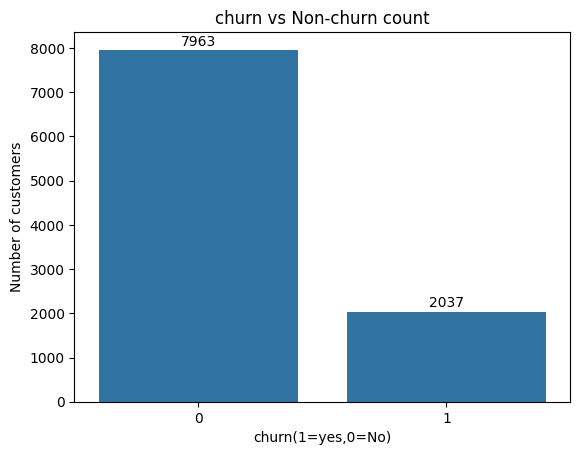

In [27]:
#Churn vs non-churn count
ax = sns.countplot(x='churn',data = df)
plt.title("churn vs Non-churn count")
plt.xlabel("churn(1=yes,0=No)")
plt.ylabel("Number of customers")
for p in ax.patches:
    count = int(p.get_height())
    x=p.get_x() + p.get_width()/2
    y=p.get_height()
    ax.text(x,y + 100,count,ha='center')

plt.show()

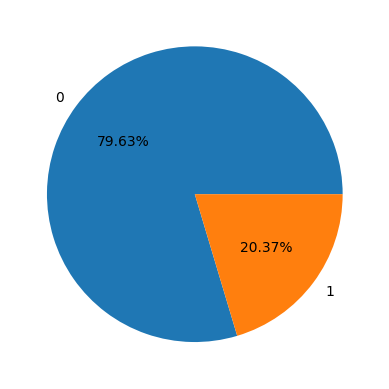

In [25]:
gb = df.groupby("churn").agg({'churn':'count'})
plt.pie(gb['churn'],labels = gb.index,autopct = "%1.2f%%")
plt.show()

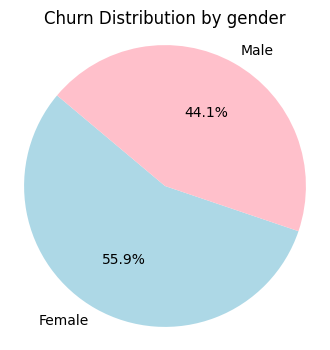

In [26]:
#Churn distribution by gender
churned = df[df['churn'] == 1]
churn_by_gender = churned['gender'].value_counts()
plt.figure(figsize=(4,4))
colors = ['lightblue','pink']
plt.pie(churn_by_gender,labels=churn_by_gender.index,autopct='%1.1f%%',startangle=140,colors=colors)
plt.title('Churn Distribution by gender')
plt.axis('equal')
plt.show()

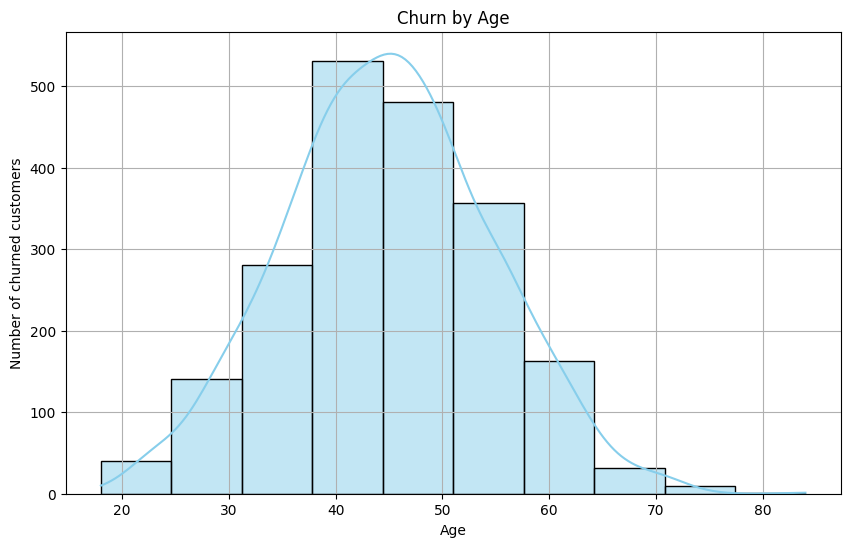

In [28]:
# churn by age
churned = df[df['churn'] == 1]
plt.figure(figsize=(10,6))
sns.histplot(data=churned,x='age',bins=10,kde=True,color='skyblue')
plt.title('Churn by Age')
plt.xlabel('Age')
plt.ylabel('Number of churned customers')
plt.grid(True)
plt.show()


Churn Rate by Tenure:
     tenure  ChurnRate (%)
0        0      23.002421
1        1      22.415459
2        2      19.179389
3        3      21.110010
4        4      20.525784
5        5      20.652174
6        6      20.268873
7        7      17.217899
8        8      19.219512
9        9      21.646341
10      10      20.612245


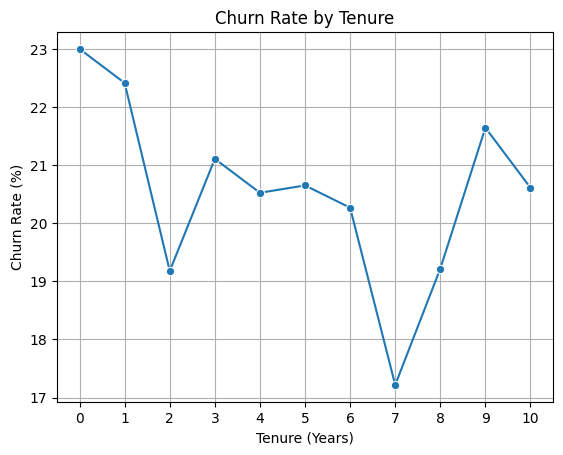

In [29]:
#churn rate by tenure
tenure_churn = df.groupby('tenure')['churn'].mean().reset_index()
tenure_churn['churn'] = tenure_churn['churn'] * 100  # convert to percentage
tenure_churn.rename(columns={'churn': 'ChurnRate (%)'}, inplace=True)


print("\nChurn Rate by Tenure:\n", tenure_churn)


sns.lineplot(x='tenure', y='ChurnRate (%)', data=tenure_churn, marker='o')
plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure (Years)")
plt.ylabel("Churn Rate (%)")
plt.xticks(range(df['tenure'].min(), df['tenure'].max() + 1))
plt.grid(True)
plt.show()

['France' 'Spain' 'Germany']

Churn Rate by Geography:
    country  ChurnRate (%)
0   France      16.154767
1  Germany      32.443204
2    Spain      16.673395


/tmp/ipykernel_2280/4233905906.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='country', y='ChurnRate (%)', data=geo_churn, palette='Set2')


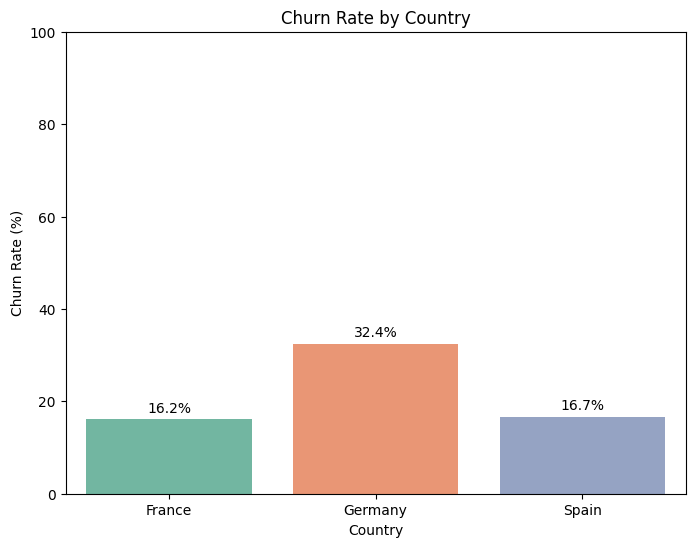

In [30]:
#Churn rate by country
print(df['country'].unique())


geo_churn = df.groupby('country')['churn'].mean().reset_index()
geo_churn['churn'] = geo_churn['churn'] * 100  # Convert to percentage
geo_churn.rename(columns={'churn': 'ChurnRate (%)'}, inplace=True)


print("\nChurn Rate by Geography:\n", geo_churn)


plt.figure(figsize=(8, 6))
barplot = sns.barplot(x='country', y='ChurnRate (%)', data=geo_churn, palette='Set2')


for i in barplot.containers:
    barplot.bar_label(i, fmt='%.1f%%', label_type='edge', padding=3)
plt.title("Churn Rate by Country")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Country")
plt.ylim(0, 100)
plt.show()

active_member
1    5151
0    4849
Name: count, dtype: int64


/tmp/ipykernel_2280/3870741197.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Status', y='ChurnRate (%)', data=active_churn, palette='pastel')


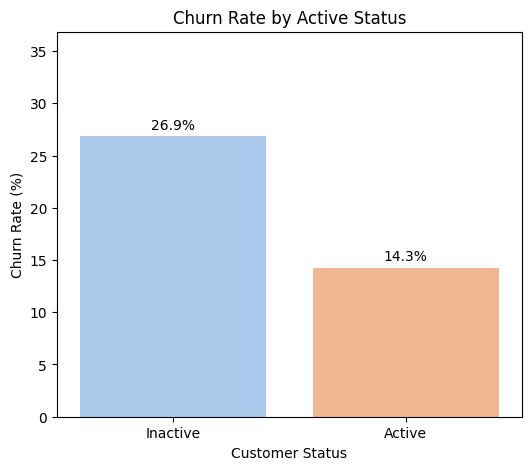


Churn Rate by Active Status:
      Status  ChurnRate (%)
0  Inactive      26.850897
1    Active      14.269074


In [31]:
#Churn rate by active status
print(df['active_member'].value_counts())


active_churn = df.groupby('active_member')['churn'].mean().reset_index()
active_churn['churn'] = active_churn['churn'] * 100  # convert to percentage
active_churn.rename(columns={'churn': 'ChurnRate (%)'}, inplace=True)


active_churn['Status'] = active_churn['active_member'].map({1: 'Active', 0: 'Inactive'})


plt.figure(figsize=(6, 5))
barplot = sns.barplot(x='Status', y='ChurnRate (%)', data=active_churn, palette='pastel')


for i in barplot.containers:
    barplot.bar_label(i, fmt='%.1f%%', label_type='edge', padding=3)

plt.title("Churn Rate by Active Status")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Customer Status")
plt.ylim(0, active_churn['ChurnRate (%)'].max() + 10)
plt.show()


print("\nChurn Rate by Active Status:\n", active_churn[['Status', 'ChurnRate (%)']])

/tmp/ipykernel_2280/2413254402.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  balance_churn = df.groupby('BalanceGroup')['churn'].mean().reset_index()
/tmp/ipykernel_2280/2413254402.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='BalanceGroup', y='ChurnRate (%)', data=balance_churn, palette='Blues')


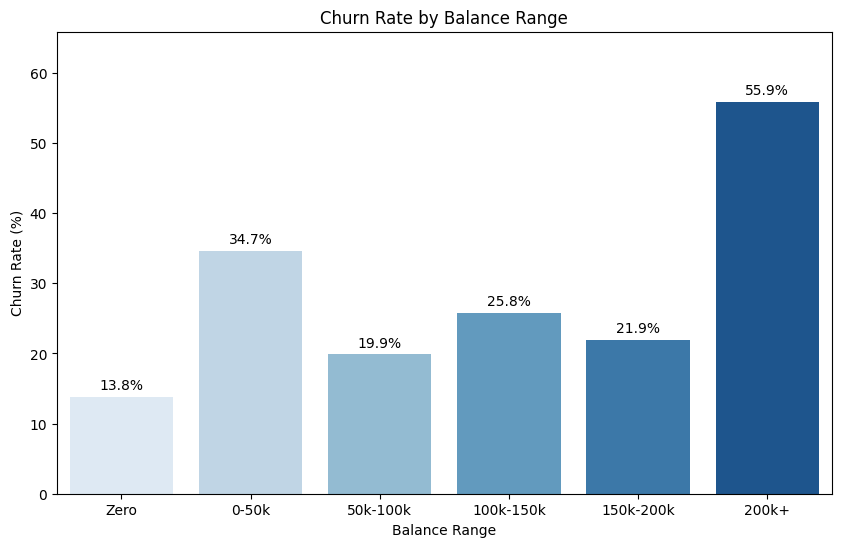


Churn Rate by Balance Group:
   BalanceGroup  ChurnRate (%)
0         Zero      13.823611
1        0-50k      34.666667
2     50k-100k      19.880716
3    100k-150k      25.770235
4    150k-200k      21.925134
5        200k+      55.882353


In [32]:
#Churn rate by balance range
bins = [0, 1, 50000, 100000, 150000, 200000, df['balance'].max()]
labels = ['Zero', '0-50k', '50k-100k', '100k-150k', '150k-200k', '200k+']

df['BalanceGroup'] = pd.cut(df['balance'], bins=bins, labels=labels, include_lowest=True)


balance_churn = df.groupby('BalanceGroup')['churn'].mean().reset_index()
balance_churn['churn'] = balance_churn['churn'] * 100
balance_churn.rename(columns={'churn': 'ChurnRate (%)'}, inplace=True)


plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='BalanceGroup', y='ChurnRate (%)', data=balance_churn, palette='Blues')


for i in barplot.containers:
    barplot.bar_label(i, fmt='%.1f%%', label_type='edge', padding=3)


plt.title("Churn Rate by Balance Range")
plt.xlabel("Balance Range")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, balance_churn['ChurnRate (%)'].max() + 10)
plt.show()


print("\nChurn Rate by Balance Group:\n", balance_churn)

/tmp/ipykernel_2280/468155651.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate_by_score, x='CreditScoreGroup', y='churn', palette='coolwarm')


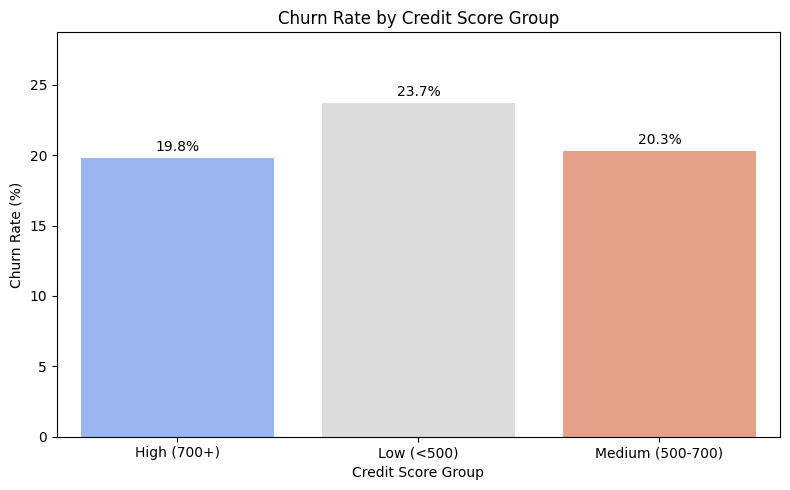

In [37]:
#Churn rate by Credit score group
def credit_score_group(score):
    if score < 500:
        return 'Low (<500)'
    elif 500 <= score < 700:
        return 'Medium (500-700)'
    else:
        return 'High (700+)'

df['CreditScoreGroup'] = df['credit_score'].apply(credit_score_group)


churn_rate_by_score = df.groupby('CreditScoreGroup')['churn'].mean().reset_index()
churn_rate_by_score['churn'] = churn_rate_by_score['churn'] * 100  # to percentage




plt.figure(figsize=(8,5))
sns.barplot(data=churn_rate_by_score, x='CreditScoreGroup', y='churn', palette='coolwarm')


for index, row in churn_rate_by_score.iterrows():
    plt.text(x=index, y=row['churn'] + 0.5, s=f"{row['churn']:.1f}%", ha='center', fontsize=10)

plt.title("Churn Rate by Credit Score Group")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Credit Score Group")
plt.ylim(0, max(churn_rate_by_score['churn']) + 5)
plt.tight_layout()
plt.show()